# Level 2：Uplift 建模 → 精準識別 Persuadables

**核心思路**：Contact 是否對捐款行為有因果效應？

$$Uplift_i = EV(Contact=1) - EV(Contact=0)$$
$$= P(gave|C=1) \times E(amt|gave,C=1) - P(gave|C=0) \times E(amt|gave,C=0)$$

| 四象限 | 定義 | 策略 |
|--------|------|---------|
| **Persuadables** | Uplift > 成本 | ✅ 聯繫 |
| **Sure Things** | EV_nocontact 高，Uplift ≈ 0 | ❌ 省成本，不聯繫 |
| **Sleeping Dogs** | Uplift < 0 | ❌ 絕對不聯繫 |
| **Lost Causes** | EV 都低 | ❌ 不聯繫 |

- 訓練資料：`R2_TRAIN`（100K 筆，含 `Contact` 欄位）
- 評分資料：`R2_CONTACT_SCOREDATA`（Contact=1）+ `R2_NOCONTACT_SCOREDATA`（Contact=0）
- 輸出：只有 ID 的 CSV，上傳排行榜

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_auc_score, classification_report, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12

In [2]:
# ============================================================
# 1. 載入 R2_TRAIN & EDA
# ============================================================

def load_and_clean(path):
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.strip('"')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.strip('"')
    num_cols = ['Contact', 'GaveThisYear', 'AmtThisYear', 'Woman', 'Age', 'Salary',
                'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency',
                'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

train = load_and_clean('data/表格_FUNDRAISE_R2_TRAIN.csv')
train = train.dropna(subset=['Contact', 'GaveThisYear', 'AmtThisYear']).reset_index(drop=True)

print(f'R2_TRAIN shape: {train.shape}')
print(f'\nContact 分布:')
print(train['Contact'].value_counts())
print(f'\nGaveThisYear by Contact:')
gave_by_contact = train.groupby('Contact')['GaveThisYear'].mean()
print(gave_by_contact.round(4))
print(f'  → 聯繫效應（捐款率提升）: +{gave_by_contact[1]-gave_by_contact[0]:.2%}')
print(f'\nAmtThisYear (donors only) by Contact:')
print(train[train['AmtThisYear']>0].groupby('Contact')['AmtThisYear'].mean().round(2))

# EV by Contact
ev0 = gave_by_contact[0] * train[train['AmtThisYear']>0]['AmtThisYear'].mean()
ev1 = gave_by_contact[1] * train[train['AmtThisYear']>0]['AmtThisYear'].mean()
print(f'\n粗估 EV (Contact=0): ${ev0:.2f}')
print(f'粗估 EV (Contact=1): ${ev1:.2f}')
print(f'粗估 Uplift:          ${ev1-ev0:.2f}')

R2_TRAIN shape: (100000, 22)

Contact 分布:
Contact
0    89886
1    10114
Name: count, dtype: int64

GaveThisYear by Contact:
Contact
0    0.1811
1    0.3991
Name: GaveThisYear, dtype: float64
  → 聯繫效應（捐款率提升）: +21.79%

AmtThisYear (donors only) by Contact:
Contact
0    66.67
1    69.61
Name: AmtThisYear, dtype: float64

粗估 EV (Contact=0): $12.18
粗估 EV (Contact=1): $26.84
粗估 Uplift:          $14.66


In [3]:
# ============================================================
# 2. 特徵工程 & 前處理
# ============================================================
# Contact 是 FEATURE（保留），GaveThisYear/AmtThisYear 是 Target（移除）

DROP_COLS = ['ID', 'LastName', 'FirstName', 'GaveThisYear', 'AmtThisYear']
CAT_COLS  = ['Education', 'City']

def preprocess(df, feature_cols=None):
    out = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    out = pd.get_dummies(out, columns=[c for c in CAT_COLS if c in out.columns], drop_first=True)
    if feature_cols is not None:
        for col in feature_cols:
            if col not in out.columns:
                out[col] = 0
        out = out[feature_cols]
    return out

X_all    = preprocess(train)
y_cls    = train['GaveThisYear'].astype(int)
y_amt    = train['AmtThisYear']
feature_cols = X_all.columns.tolist()

print(f'特徵數: {len(feature_cols)}')
print(f'特徵: {feature_cols}')
print(f'\nContact 在特徵中: {"Contact" in feature_cols}')

特徵數: 20
特徵: ['Contact', 'Woman', 'Age', 'Salary', 'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency', 'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear', 'Education_High School', 'Education_University / College', 'City_Downtown', 'City_Rural', 'City_Suburban']

Contact 在特徵中: True


In [4]:
# ============================================================
# 3. 切分資料 & 訓練分類模型 P(GaveThisYear=1)
# ============================================================

X_train, X_val, y_cls_train, y_cls_val, y_amt_train, y_amt_val = train_test_split(
    X_all, y_cls, y_amt, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
X_train_sc = scaler_cls.fit_transform(X_train)
X_val_sc   = scaler_cls.transform(X_val)

clf = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
clf.fit(X_train_sc, y_cls_train)

y_proba_val = clf.predict_proba(X_val_sc)[:, 1]
auc = roc_auc_score(y_cls_val, y_proba_val)
print(f'分類模型 AUC: {auc:.4f}')
print(classification_report(y_cls_val, (y_proba_val >= 0.5).astype(int),
                             target_names=['未捐(0)', '有捐(1)']))

# Feature importance 前十
fi = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('Top 10 重要特徵:')
print(fi.head(10).round(4))

分類模型 AUC: 0.7051
              precision    recall  f1-score   support

       未捐(0)       0.82      0.98      0.89     15937
       有捐(1)       0.62      0.13      0.21      4063

    accuracy                           0.81     20000
   macro avg       0.72      0.55      0.55     20000
weighted avg       0.77      0.81      0.75     20000

Top 10 重要特徵:
Contact         0.2086
NbActivities    0.1743
SeniorList      0.1098
Referrals       0.1034
Frequency       0.0874
Age             0.0700
Woman           0.0421
AmtLastYear     0.0386
Salary          0.0383
Recency         0.0368
dtype: float64


In [5]:
# ============================================================
# 4. 訓練回歸模型 E(AmtThisYear | GaveThisYear=1)
# ============================================================

donor_mask_train = y_amt_train > 0
donor_mask_val   = y_amt_val   > 0

X_donors_train = X_train[donor_mask_train]
y_donors_train = y_amt_train[donor_mask_train]
X_donors_val   = X_val[donor_mask_val]
y_donors_val   = y_amt_val[donor_mask_val]

scaler_reg = StandardScaler()
X_donors_train_sc = scaler_reg.fit_transform(X_donors_train)
X_donors_val_sc   = scaler_reg.transform(X_donors_val)

y_log_train = np.log1p(y_donors_train)
y_log_val   = np.log1p(y_donors_val)

reg = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
reg.fit(X_donors_train_sc, y_log_train)

y_pred_log = reg.predict(X_donors_val_sc)
y_pred_amt = np.expm1(y_pred_log).clip(min=0)

r2_log  = r2_score(y_log_val,   y_pred_log)
r2_orig = r2_score(y_donors_val, y_pred_amt)
mae     = mean_absolute_error(y_donors_val, y_pred_amt)

print(f'回歸模型 (僅捐款者, log 訓練):')
print(f'  R² (log space):  {r2_log:.4f}')
print(f'  R² (orig space): {r2_orig:.4f}')
print(f'  MAE:  ${mae:.2f}')
print(f'  捐款者數: train={len(X_donors_train)}, val={len(X_donors_val)}')

回歸模型 (僅捐款者, log 訓練):
  R² (log space):  0.0155
  R² (orig space): -0.0184
  MAE:  $51.55
  捐款者數: train=16252, val=4063


驗證集 Uplift 策略:
  Uplift > 成本:   聯繫 11,526 人, Surplus = $121,965
  真實最佳:        聯繫 19,996 人, Surplus = $173,395
  全部聯繫:        Surplus = $173,375
  策略效率: 70.3%

Uplift 分布:
  正 Uplift (Persuadables候選): 18,804
  負 Uplift (Sleeping Dogs候選): 1,196

四象限分布 (驗證集):
quadrant
Persuadable     11526
Lost Cause       4109
Sure Thing       3169
Sleeping Dog     1196
Name: count, dtype: int64


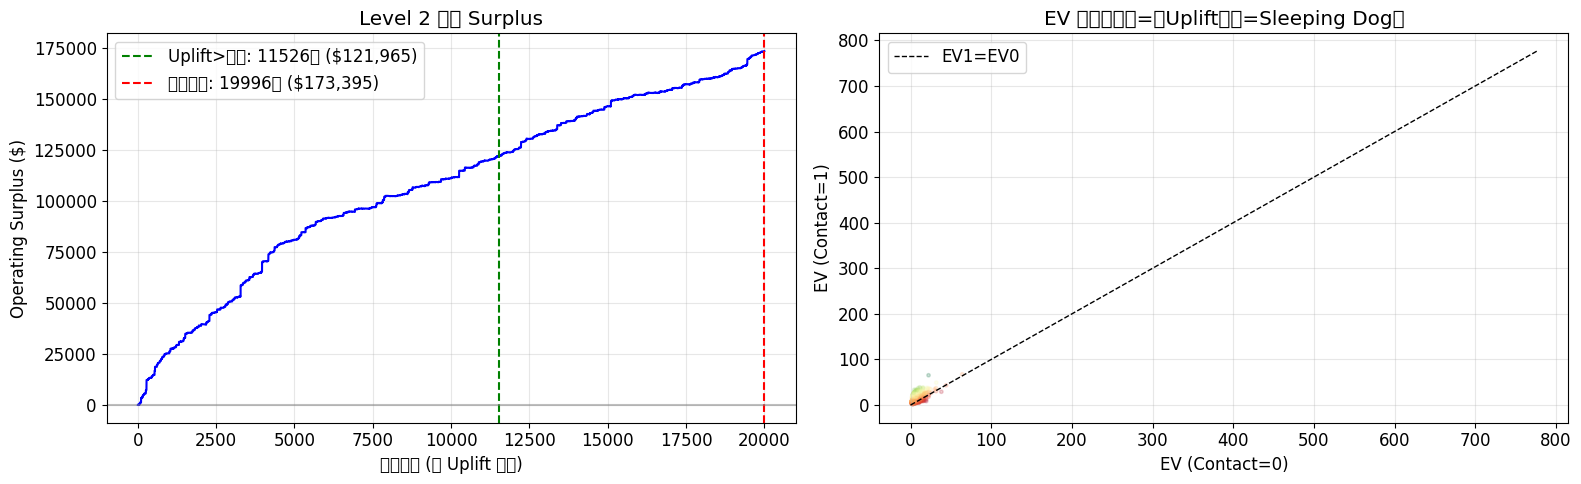

In [6]:
# ============================================================
# 5. Uplift 驗證：在驗證集模擬 Contact=1 vs Contact=0
# ============================================================
# 將同一批驗證集分別設定 Contact=1 和 Contact=0，預測兩種情境

COST_SCHEDULE = [
    (60_000, 5),
    (np.inf, 25),
]

def calc_total_cost(n, schedule):
    total, remaining, prev = 0, n, 0
    for limit, cost in schedule:
        tier = min(remaining, limit - prev)
        if tier <= 0: break
        total += tier * cost
        remaining -= tier
        prev = limit
    return total

def get_marginal_cost(rank, schedule):
    for limit, cost in schedule:
        if rank <= limit:
            return cost
    return schedule[-1][1]

def score_with_contact(X_df, contact_val, clf, scaler_cls, reg, scaler_reg):
    """複製 X_df 並強制設定 Contact，回傳 P_gave, E_amt, EV"""
    Xc = X_df.copy()
    Xc['Contact'] = contact_val
    Xsc = scaler_cls.transform(Xc)
    P = clf.predict_proba(Xsc)[:, 1]
    E = np.expm1(reg.predict(scaler_reg.transform(Xc))).clip(min=0)
    return P, E, P * E

P1_val, E1_val, EV1_val = score_with_contact(X_val, 1, clf, scaler_cls, reg, scaler_reg)
P0_val, E0_val, EV0_val = score_with_contact(X_val, 0, clf, scaler_cls, reg, scaler_reg)
uplift_val = EV1_val - EV0_val

val_df = pd.DataFrame({
    'EV_contact':   EV1_val,
    'EV_nocontact': EV0_val,
    'uplift':       uplift_val,
    'actual_gave':  y_cls_val.values,
    'actual_amt':   y_amt_val.values,
    'true_contact': X_val['Contact'].values,  # 實際是否有被聯繫
}).sort_values('uplift', ascending=False).reset_index(drop=True)

val_df['rank']          = range(1, len(val_df)+1)
val_df['marginal_cost'] = val_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
val_df['cum_donation']  = val_df['actual_amt'].cumsum()
val_df['cum_cost']      = val_df['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
val_df['cum_surplus']   = val_df['cum_donation'] - val_df['cum_cost']

# Uplift > 邊際成本策略
our_mask    = val_df['uplift'] > val_df['marginal_cost']
our_n       = our_mask.sum()
our_surplus = val_df.loc[our_n-1, 'cum_surplus'] if our_n > 0 else 0
best_n      = val_df['cum_surplus'].idxmax() + 1
best_surplus= val_df['cum_surplus'].max()

print(f'驗證集 Uplift 策略:')
print(f'  Uplift > 成本:   聯繫 {our_n:,} 人, Surplus = ${our_surplus:,.0f}')
print(f'  真實最佳:        聯繫 {best_n:,} 人, Surplus = ${best_surplus:,.0f}')
print(f'  全部聯繫:        Surplus = ${val_df["cum_surplus"].iloc[-1]:,.0f}')
print(f'  策略效率: {our_surplus/best_surplus:.1%}' if best_surplus > 0 else '')
print(f'\nUplift 分布:')
print(f'  正 Uplift (Persuadables候選): {(uplift_val>0).sum():,}')
print(f'  負 Uplift (Sleeping Dogs候選): {(uplift_val<0).sum():,}')

# 四象限分類
SURE_THING_THRESHOLD = 5     # EV_nocontact > $5 視為 Sure Thing
SLEEPING_DOG_THRESHOLD = 0

def classify_quadrant(row):
    if row['uplift'] > row['marginal_cost']:
        return 'Persuadable'
    elif row['EV_nocontact'] > SURE_THING_THRESHOLD and row['uplift'] >= SLEEPING_DOG_THRESHOLD:
        return 'Sure Thing'
    elif row['uplift'] < SLEEPING_DOG_THRESHOLD:
        return 'Sleeping Dog'
    else:
        return 'Lost Cause'

val_df['quadrant'] = val_df.apply(classify_quadrant, axis=1)
print(f'\n四象限分布 (驗證集):')
print(val_df['quadrant'].value_counts())

# 視覺化
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(val_df['rank'], val_df['cum_surplus'], 'b-', lw=1.5)
ax.axvline(our_n,  color='green', ls='--', label=f'Uplift>成本: {our_n}人 (${our_surplus:,.0f})')
ax.axvline(best_n, color='red',   ls='--', label=f'真實最佳: {best_n}人 (${best_surplus:,.0f})')
ax.axhline(0, color='gray', alpha=0.5)
ax.set_xlabel('聯繫人數 (按 Uplift 降序)')
ax.set_ylabel('Operating Surplus ($)')
ax.set_title('Level 2 累積 Surplus')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(EV0_val[:2000], EV1_val[:2000], alpha=0.2, s=6, c=uplift_val[:2000], cmap='RdYlGn')
ax.plot([0, EV0_val.max()], [0, EV0_val.max()], 'k--', lw=1, label='EV1=EV0')
ax.set_xlabel('EV (Contact=0)')
ax.set_ylabel('EV (Contact=1)')
ax.set_title('EV 散佈圖（綠=高Uplift，紅=Sleeping Dog）')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 6. 用全量資料重新訓練 → 對兩份 SCOREDATA 評分
# ============================================================

scaler_cls_full = StandardScaler()
X_all_sc = scaler_cls_full.fit_transform(X_all)
clf_full = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
clf_full.fit(X_all_sc, y_cls)
print('分類模型（全資料）訓練完成')

donor_mask_all = y_amt > 0
X_donors_all   = X_all[donor_mask_all]
y_donors_all   = y_amt[donor_mask_all]
scaler_reg_full = StandardScaler()
X_donors_all_sc = scaler_reg_full.fit_transform(X_donors_all)
reg_full = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
reg_full.fit(X_donors_all_sc, np.log1p(y_donors_all))
print(f'回歸模型（全資料）訓練完成，捐款者: {len(X_donors_all)}')

# --- 載入兩份 SCOREDATA ---
score_c  = load_and_clean('data/表格_FUNDRAISE_R2_CONTACT_SCOREDATA.csv')    # Contact=1
score_nc = load_and_clean('data/表格_FUNDRAISE_R2_NOCONTACT_SCOREDATA.csv')  # Contact=0

assert len(score_c) == len(score_nc), 'SCOREDATA 筆數不一致！'
assert (score_c['ID'].values == score_nc['ID'].values).all(), 'ID 順序不一致！'
print(f'\nCONTACT SCOREDATA:   {score_c.shape}')
print(f'NOCONTACT SCOREDATA: {score_nc.shape}')

score_ids = score_c['ID'].copy()

def score_scoredata(df, clf, scaler_cls, reg, scaler_reg, feature_cols):
    X = preprocess(df, feature_cols=feature_cols)
    P = clf.predict_proba(scaler_cls.transform(X))[:, 1]
    E = np.expm1(reg.predict(scaler_reg.transform(X))).clip(min=0)
    return P, E, P * E

P1, E1, EV1 = score_scoredata(score_c,  clf_full, scaler_cls_full, reg_full, scaler_reg_full, feature_cols)
P0, E0, EV0 = score_scoredata(score_nc, clf_full, scaler_cls_full, reg_full, scaler_reg_full, feature_cols)

uplift = EV1 - EV0

print(f'\nUplift 統計:')
print(f'  平均: ${uplift.mean():.2f}')
print(f'  中位: ${np.median(uplift):.2f}')
print(f'  正值: {(uplift>0).sum():,} 人')
print(f'  負值（Sleeping Dogs）: {(uplift<0).sum():,} 人')

分類模型（全資料）訓練完成
回歸模型（全資料）訓練完成，捐款者: 20315

CONTACT SCOREDATA:   (100000, 20)
NOCONTACT SCOREDATA: (100000, 20)

Uplift 統計:
  平均: $6.54
  中位: $5.47
  正值: 92,477 人
  負值（Sleeping Dogs）: 7,523 人


四象限分布 (SCOREDATA):
quadrant
Persuadable     53277
Lost Cause      20842
Sure Thing      18358
Sleeping Dog     7523
Name: count, dtype: int64

聯繫名單:
  Persuadables:  53,277 人
  Sure Things:   18,358 人（省下成本）
  Sleeping Dogs: 7,523 人（避開）
  Lost Causes:   20,842 人
  預估成本: $266,385


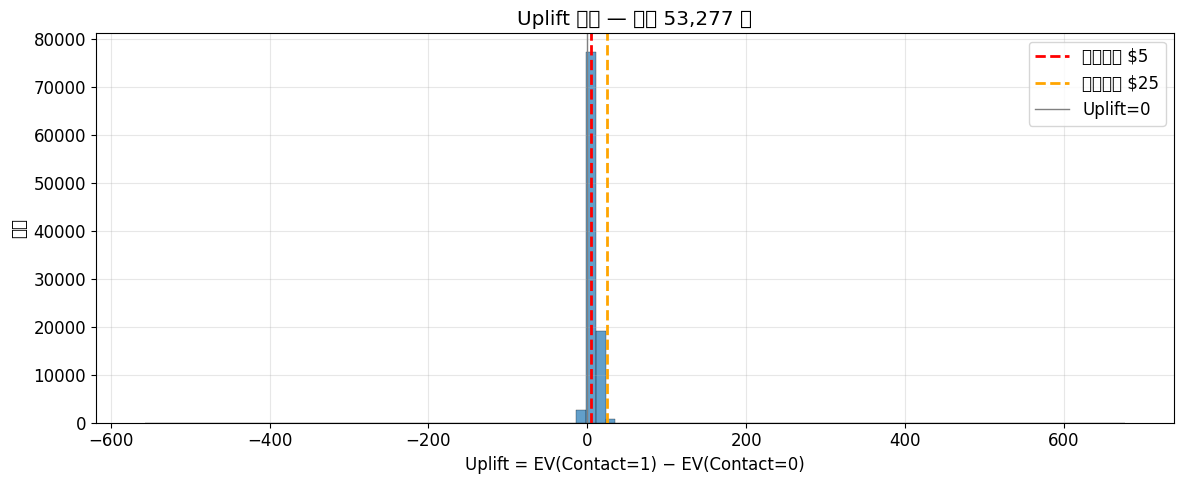


已匯出 53,277 個 ID → output/level2_contact_list.csv

前 10 筆 Persuadables:
     ID  P_contact  P_nocontact  EV_contact  EV_nocontact     uplift
2527387   0.763064     0.336580 1218.459479    541.773525 676.685954
2432017   0.602220     0.242057  227.747294     47.274514 180.472779
2684038   0.819681     0.507723  737.672572    575.953418 161.719154
2145870   0.758151     0.383872  281.643391    157.538346 124.105045
2655021   0.645360     0.225732  187.632578     66.319261 121.313317
2773118   0.494753     0.076230  139.566324     23.659329 115.906995
2420891   0.839674     0.666990  621.057870    513.858060 107.199809
2361241   0.500659     0.140399  126.678978     21.551196 105.127782
2043677   0.746052     0.336164  214.041806    109.975225 104.066581
2073327   0.588459     0.207452  159.951071     60.265437  99.685634


In [8]:
# ============================================================
# 7. 篩選聯繫名單 & 匯出
# ============================================================

score_df = pd.DataFrame({
    'ID':           score_ids.values,
    'P_contact':    P1,
    'P_nocontact':  P0,
    'E_contact':    E1,
    'E_nocontact':  E0,
    'EV_contact':   EV1,
    'EV_nocontact': EV0,
    'uplift':       uplift,
}).sort_values('uplift', ascending=False).reset_index(drop=True)

score_df['rank']          = range(1, len(score_df)+1)
score_df['marginal_cost'] = score_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

def classify_quadrant_score(row):
    if row['uplift'] > row['marginal_cost']:
        return 'Persuadable'
    elif row['EV_nocontact'] > SURE_THING_THRESHOLD and row['uplift'] >= 0:
        return 'Sure Thing'
    elif row['uplift'] < 0:
        return 'Sleeping Dog'
    else:
        return 'Lost Cause'

score_df['quadrant'] = score_df.apply(classify_quadrant_score, axis=1)

print('四象限分布 (SCOREDATA):')
print(score_df['quadrant'].value_counts())

# 只聯繫 Persuadables
contact = score_df[score_df['quadrant'] == 'Persuadable'].copy()

n_contact  = len(contact)
total_cost = calc_total_cost(n_contact, COST_SCHEDULE)

print(f'\n聯繫名單:')
print(f'  Persuadables:  {n_contact:,} 人')
print(f'  Sure Things:   {(score_df["quadrant"]=="Sure Thing").sum():,} 人（省下成本）')
print(f'  Sleeping Dogs: {(score_df["quadrant"]=="Sleeping Dog").sum():,} 人（避開）')
print(f'  Lost Causes:   {(score_df["quadrant"]=="Lost Cause").sum():,} 人')
print(f'  預估成本: ${total_cost:,.0f}')

# Uplift 分布圖
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(uplift, bins=100, alpha=0.7, edgecolor='black', lw=0.3)
ax.axvline(5,  color='red',    ls='--', lw=2, label='成本門檻 $5')
ax.axvline(25, color='orange', ls='--', lw=2, label='成本門檻 $25')
ax.axvline(0,  color='gray',   ls='-',  lw=1, label='Uplift=0')
ax.set_xlabel('Uplift = EV(Contact=1) − EV(Contact=0)')
ax.set_ylabel('人數')
ax.set_title(f'Uplift 分布 — 聯繫 {n_contact:,} 人')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 匯出
import os
os.makedirs('output', exist_ok=True)
output_path = 'output/level2_contact_list.csv'
contact[['ID']].to_csv(output_path, index=False)
print(f'\n已匯出 {n_contact:,} 個 ID → {output_path}')
print(f'\n前 10 筆 Persuadables:')
print(contact[['ID','P_contact','P_nocontact','EV_contact','EV_nocontact','uplift']].head(10).to_string(index=False))